# F1 Radio — Model Training

**Architecture:** DistilBERT (text) + acoustic MLP (pitch features) → fusion head

**Label map:** 0=Calm, 1=Frustrated, 2=High Stress, 3=Urgent

**Loss:** CrossEntropyLoss with class weights (Calm=0.35, Frustrated=3.76, High Stress=2.21, Urgent=2.47)

**Metric:** Macro F1 (accuracy is useless — Calm is 72% of data)

In [4]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

BASE   = r'C:\Users\Ritarshi Roy\OneDrive\Desktop\Projects\F1 Recordings'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Hyperparameters ──────────────────────────────────────────────────────────
MAX_LEN    = 128   # max tokens per clip (most F1 radio is <50 words)
BATCH_SIZE = 16
EPOCHS     = 20
LR         = 1e-4
DROPOUT    = 0.5
PATIENCE = 4

LABEL_ORDER = ['Calm', 'Frustrated', 'High Stress']
NUM_CLASSES = 3
ACOUSTIC_COLS = ['mean_pitch', 'pitch_range', 'pitch_std']  # energy/ZCR don't separate classes

Using device: cpu


## 1. Load Data & Class Weights

In [5]:
train_df = pd.read_csv(os.path.join(BASE, 'data', 'splits', 'train.csv'))
val_df   = pd.read_csv(os.path.join(BASE, 'data', 'splits', 'val.csv'))
test_df  = pd.read_csv(os.path.join(BASE, 'data', 'splits', 'test.csv'))

# Replace NaN clean_text with empty string (edge case)
for df in [train_df, val_df, test_df]:
    df['clean_text'] = df['clean_text'].fillna('')

# Load class weights
with open(os.path.join(BASE, 'annotations', 'class_weights.json')) as f:
    cw_data = json.load(f)
weight_list = [cw_data['by_id'][str(i)] for i in range(NUM_CLASSES)]
class_weights = torch.tensor(weight_list, dtype=torch.float).to(DEVICE)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print(f'Class weights: {dict(zip(LABEL_ORDER, weight_list))}')

Train: 914  Val: 196  Test: 196
Class weights: {'Calm': 0.4631, 'Frustrated': 5.0, 'High Stress': 1.5607}


## 2. Normalise Acoustic Features

Fit the scaler **only on train** — apply the same scaler to val and test (no data leakage).

In [6]:
scaler = StandardScaler()
train_df[ACOUSTIC_COLS] = scaler.fit_transform(train_df[ACOUSTIC_COLS])
val_df[ACOUSTIC_COLS]   = scaler.transform(val_df[ACOUSTIC_COLS])
test_df[ACOUSTIC_COLS]  = scaler.transform(test_df[ACOUSTIC_COLS])

# Save scaler so we can use it at inference time
import pickle
scaler_path = os.path.join(BASE, 'models', 'scaler.pkl')
os.makedirs(os.path.join(BASE, 'models'), exist_ok=True)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved to {scaler_path}')
print(f'Acoustic means (train): {dict(zip(ACOUSTIC_COLS, scaler.mean_.round(1)))}')

Scaler saved to C:\Users\Ritarshi Roy\OneDrive\Desktop\Projects\F1 Recordings\models\scaler.pkl
Acoustic means (train): {'mean_pitch': np.float64(137.9), 'pitch_range': np.float64(298.9), 'pitch_std': np.float64(64.5)}


## 3. Dataset & DataLoader

In [7]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class F1RadioDataset(Dataset):
    def __init__(self, df):
        self.texts    = df['clean_text'].tolist()
        self.acoustic = df[ACOUSTIC_COLS].values.astype(np.float32)
        self.labels   = df['label_id'].values.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'acoustic':       torch.tensor(self.acoustic[idx]),
            'label':          torch.tensor(self.labels[idx])
        }

train_loader = DataLoader(F1RadioDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(F1RadioDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(F1RadioDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train batches: 58  Val batches: 13


## 4. Model Architecture

```
Text: DistilBERT → CLS (768d)
Acoustic: [pitch, pitch_range, pitch_std] → Linear(3→64) → ReLU → Linear(64→32)
Fusion: concat(800d) → Linear(800→256) → ReLU → Dropout → Linear(256→4)
```

In [8]:
class F1EmotionModel(nn.Module):
    def __init__(self, num_acoustic=3, num_classes=4, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Acoustic MLP
        self.acoustic_mlp = nn.Sequential(
            nn.Linear(num_acoustic, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Fusion head
        self.classifier = nn.Sequential(
            nn.Linear(768 + 32, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, acoustic):
        # Text branch: take CLS token embedding
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb  = bert_out.last_hidden_state[:, 0, :]  # (B, 768)

        # Acoustic branch
        acoustic_emb = self.acoustic_mlp(acoustic)  # (B, 32)

        # Fuse and classify
        fused  = torch.cat([cls_emb, acoustic_emb], dim=1)  # (B, 800)
        logits = self.classifier(fused)  # (B, 4)
        return logits

model = F1EmotionModel().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Total params:     66,571,300
Trainable params: 66,571,300


## 5. Optimiser & Scheduler

In [9]:
from transformers import get_linear_schedule_with_warmup

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer,
                num_warmup_steps=warmup_steps,
                num_training_steps=total_steps)

print(f'Total steps: {total_steps}  Warmup steps: {warmup_steps}')

NameError: name 'WARMUP_RATIO' is not defined

## 6. Training Loop

In [ ]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(train):
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            acoustic       = batch['acoustic'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            logits = model(input_ids, attention_mask, acoustic)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1, all_labels, all_preds

## 7. Train

Training saves the best checkpoint (by val macro F1) to `models/best_model.pt`.

In [ ]:
best_val_f1     = 0.0
best_model_path = os.path.join(BASE, 'models', 'best_model.pt')
history         = []

header = "{:<6} {:<12} {:<10} {:<12} {:<10} {}".format(
    'Epoch', 'Train Loss', 'Train F1', 'Val Loss', 'Val F1', 'Status')
print(header)
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1, _, _ = run_epoch(train_loader, train=True)
    val_loss,   val_f1,   _, _ = run_epoch(val_loader,   train=False)

    saved = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        saved = 'saved'

    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_f1': train_f1,
                    'val_loss': val_loss, 'val_f1': val_f1})
    print("{:<6} {:<12.4f} {:<10.4f} {:<12.4f} {:<10.4f} {}".format(
        epoch, train_loss, train_f1, val_loss, val_f1, saved))

print(f'\nBest val macro F1: {best_val_f1:.4f}')

Epoch  Train Loss   Train F1   Val Loss     Val F1     Status
-----------------------------------------------------------------
1      1.3896       0.2312     1.3584       0.3211     saved
2      1.3500       0.2631     1.2883       0.2749     
3      1.2543       0.3711     1.1928       0.3675     saved
4      1.0872       0.4860     1.1994       0.3733     saved
5      0.8919       0.5957     1.1589       0.3989     saved
6      0.6983       0.6815     1.1976       0.3814     
7      0.5259       0.7972     1.2942       0.3331     
8      0.4059       0.8197     1.3532       0.3875     
9      0.3238       0.8833     1.3972       0.3825     
10     0.2650       0.9235     1.4370       0.3887     

Best val macro F1: 0.3989


## 8. Evaluate on Test Set

Load best checkpoint and run the held-out test set.

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
test_loss, test_f1, test_labels, test_preds = run_epoch(test_loader, train=False)

print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Macro F1: {test_f1:.4f}')
print()
print(classification_report(test_labels, test_preds,
                             target_names=LABEL_ORDER, zero_division=0))

Test Loss:     1.3301
Test Macro F1: 0.3388

              precision    recall  f1-score   support

        Calm       0.76      0.56      0.65       125
  Frustrated       0.22      0.33      0.27        12
 High Stress       0.18      0.15      0.16        20
      Urgent       0.19      0.53      0.28        17

    accuracy                           0.49       174
   macro avg       0.34      0.39      0.34       174
weighted avg       0.60      0.49      0.53       174



## 9. Confusion Matrix

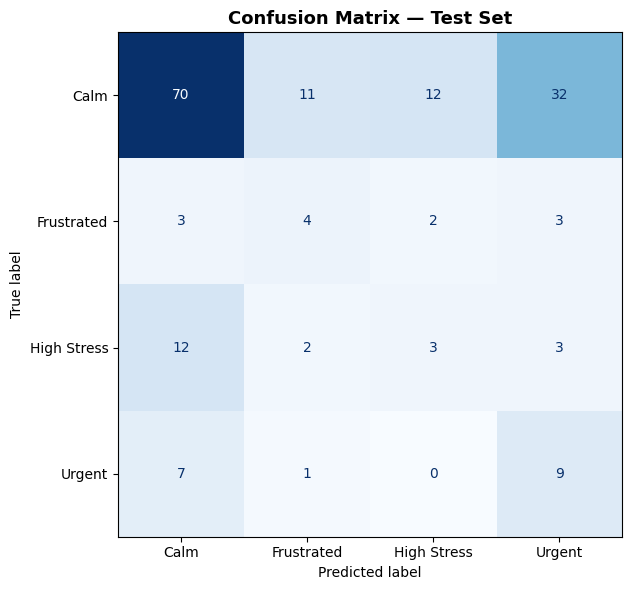

Saved to models/confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'models', 'confusion_matrix.png'), dpi=150)
plt.show()
print('Saved to models/confusion_matrix.png')

## 10. Training Curve

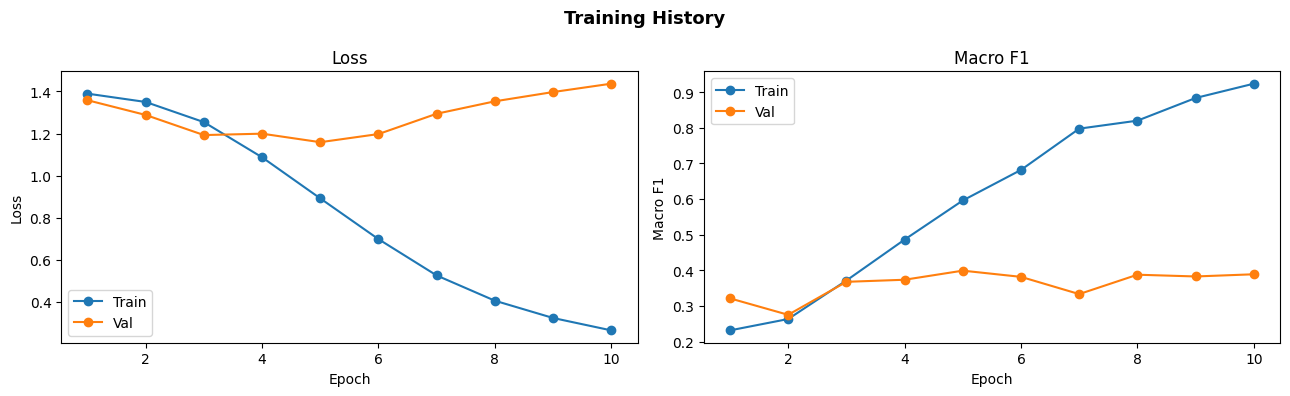

Saved to models/training_curve.png


In [ ]:
hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train', marker='o')
ax1.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val',   marker='o')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title('Loss')

ax2.plot(hist_df['epoch'], hist_df['train_f1'], label='Train', marker='o')
ax2.plot(hist_df['epoch'], hist_df['val_f1'],   label='Val',   marker='o')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1'); ax2.legend(); ax2.set_title('Macro F1')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'models', 'training_curve.png'), dpi=150)
plt.show()
print('Saved to models/training_curve.png')